# scEU-seq organoid

This tutorial uses the intestine organoid data from Battich, et al (2020). This tutorial is the second one of the two tutorials for demonstrating how dynamo can use used to analyze the scEU-seq data. Please refer the [cell cycle](https://dynamo-release.readthedocs.io/en/latest/scEU_seq_rpe1_analysis_kinetic.html) tutorial for details on how to analyze the cell cycle dataset.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import dynamo as dyn
import anndata
import pandas as pd
import numpy as np
import scipy.sparse

from anndata import AnnData
from scipy.sparse import csr_matrix

dyn.configuration.set_figure_params('dynamo', background='white')
dyn.get_all_dependencies_version()

package,umap-learn,typing-extensions,tqdm,statsmodels,setuptools,session-info,seaborn,scipy,pynndescent,pre-commit,pandas,openpyxl,numdifftools,numba,networkx,mudata,matplotlib,loompy,leidenalg,igraph,dynamo-release,colorcet,anndata
version,0.5.7,4.13.2,4.67.1,0.14.4,79.0.0,1.0.1,0.13.2,1.15.2,0.5.13,4.2.0,2.2.3,3.1.5,0.9.41,0.61.2,3.4.2,0.3.1,3.10.1,3.0.8,0.10.2,0.11.8,1.4.2rc1,3.1.0,0.11.4


## Load data

In [2]:
organoid = dyn.sample_data.scEU_seq_organoid()

|-----> Downloading scEU_seq data
|-----> Downloading data to ./data/organoid.h5ad
|-----> File ./data/organoid.h5ad already exists.


In [3]:
organoid

AnnData object with n_obs × n_vars = 3831 × 9157
    obs: 'well_id', 'batch_id', 'treatment_id', 'log10_gfp', 'rotated_umap1', 'rotated_umap2', 'som_cluster_id', 'monocle_branch_id', 'monocle_pseudotime', 'exp_type', 'time'
    var: 'ID', 'NAME'
    layers: 'sl', 'su', 'ul', 'uu'

In [4]:
# mapping:
cell_mapper = {
    '1': 'Enterocytes',
    '2': 'Enterocytes',
    '3': 'Enteroendocrine',
    '4': 'Enteroendocrine progenitor',
    '5': 'Tuft cells',
    '6': 'TA cells',
    '7': 'TA cells',
    '8': 'Stem cells',
    '9': 'Paneth cells',
    '10': 'Goblet cells',
    '11': 'Stem cells',
 }

organoid.obs['cell_type'] = organoid.obs.som_cluster_id.map(cell_mapper).astype('str')


## typical dynamo analysis workflow


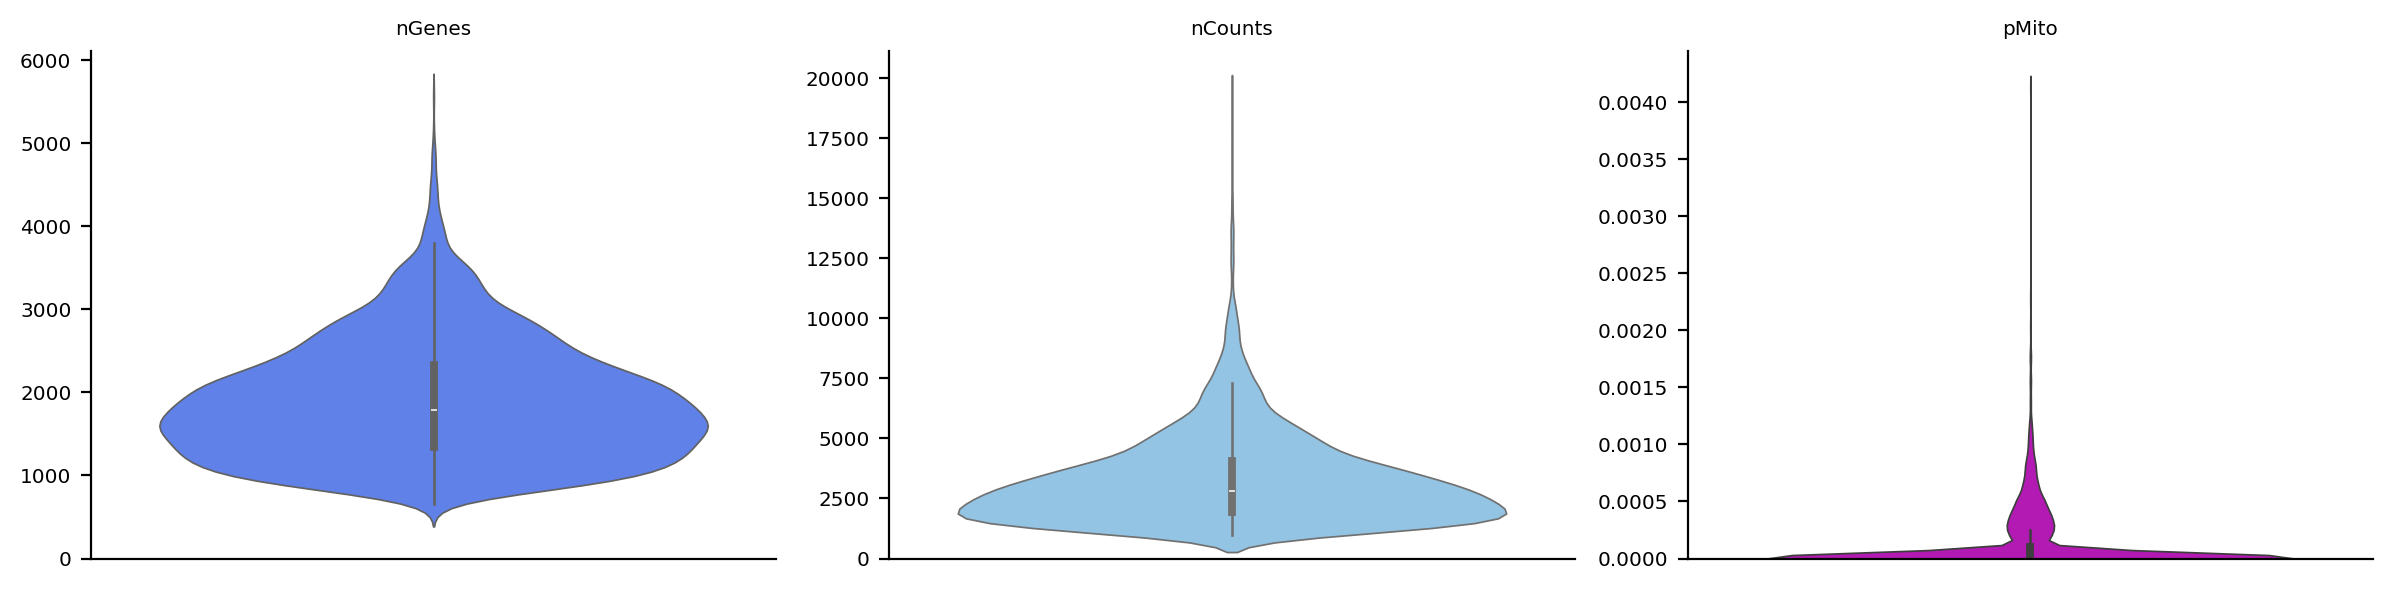

In [5]:
dyn.pl.basic_stats(organoid)

In [6]:
organoid

AnnData object with n_obs × n_vars = 3831 × 9157
    obs: 'well_id', 'batch_id', 'treatment_id', 'log10_gfp', 'rotated_umap1', 'rotated_umap2', 'som_cluster_id', 'monocle_branch_id', 'monocle_pseudotime', 'exp_type', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito'
    var: 'ID', 'NAME', 'nCells', 'nCounts'
    layers: 'sl', 'su', 'ul', 'uu'

|-----? dynamo.preprocessing.deprecated is deprecated.
|-----> recipe_monocle_keep_filtered_cells_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_cells_key=True
|-----> recipe_monocle_keep_filtered_genes_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_filtered_genes_key=True
|-----> recipe_monocle_keep_raw_layers_key is None. Using default value from DynamoAdataConfig: recipe_monocle_keep_raw_layers_key=True
|-----> apply Monocole recipe to adata...
|-----> ensure all cell and variable names unique.
|-----> ensure all data in different layers in csr sparse matrix format.
|-----> ensure all labeling data properly collapased
|-----? 
When analyzing labeling based scRNA-seq without providing `tkey`, dynamo will try to use 
 `time` as the key for labeling time. Please correct this via supplying the correct `tkey`
if needed.
|-----> detected experiment type: one-shot
|-----? Looks like you are using minutes as the time unit.

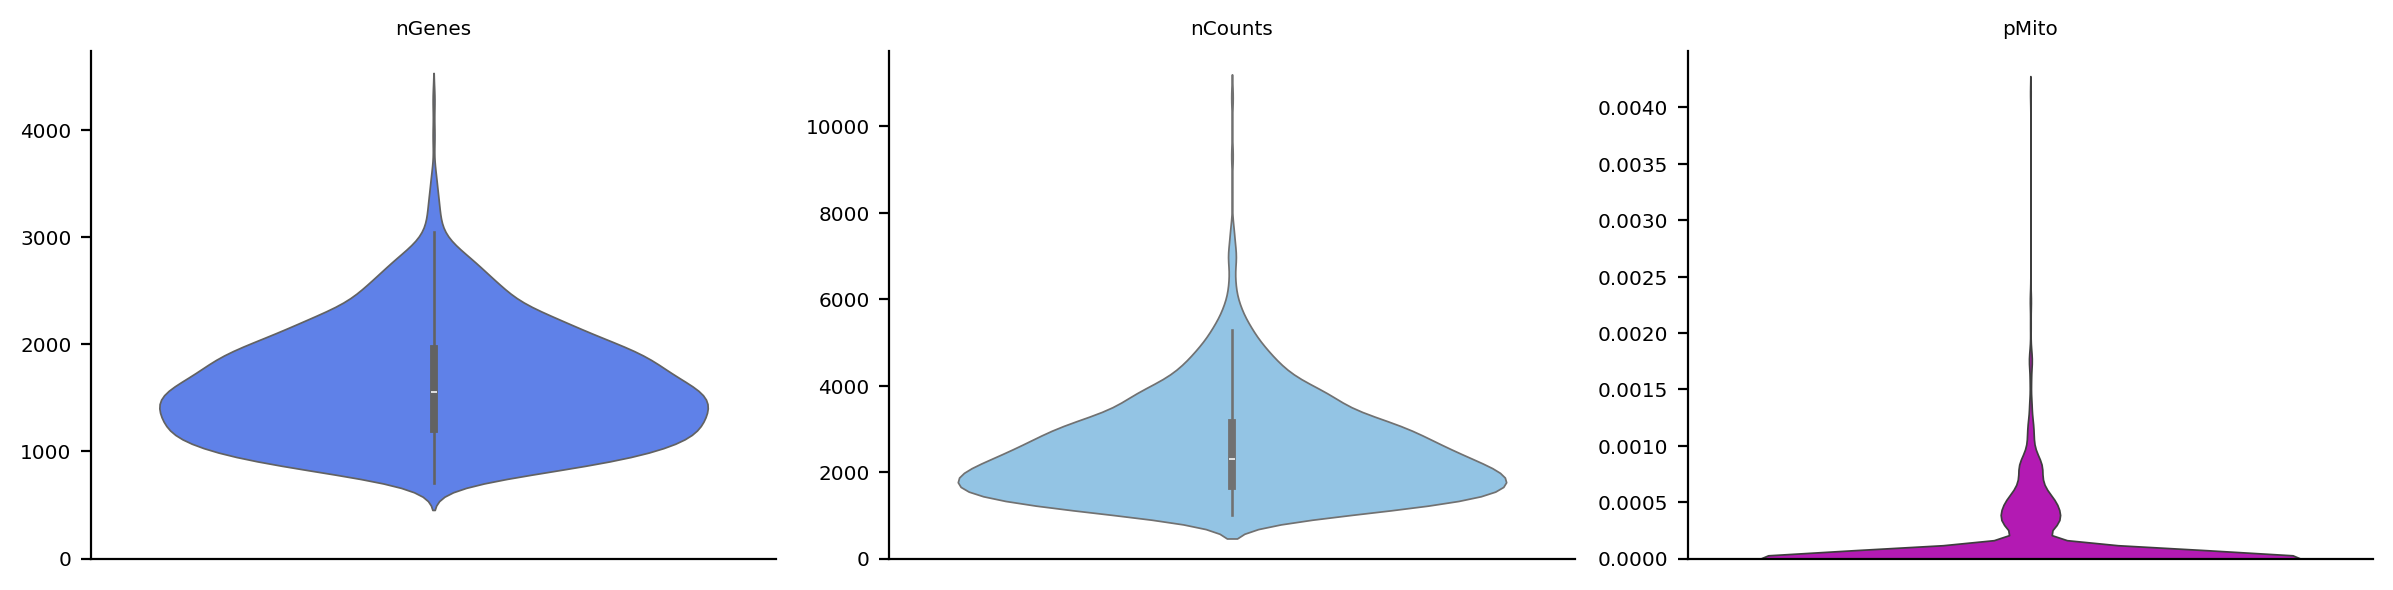

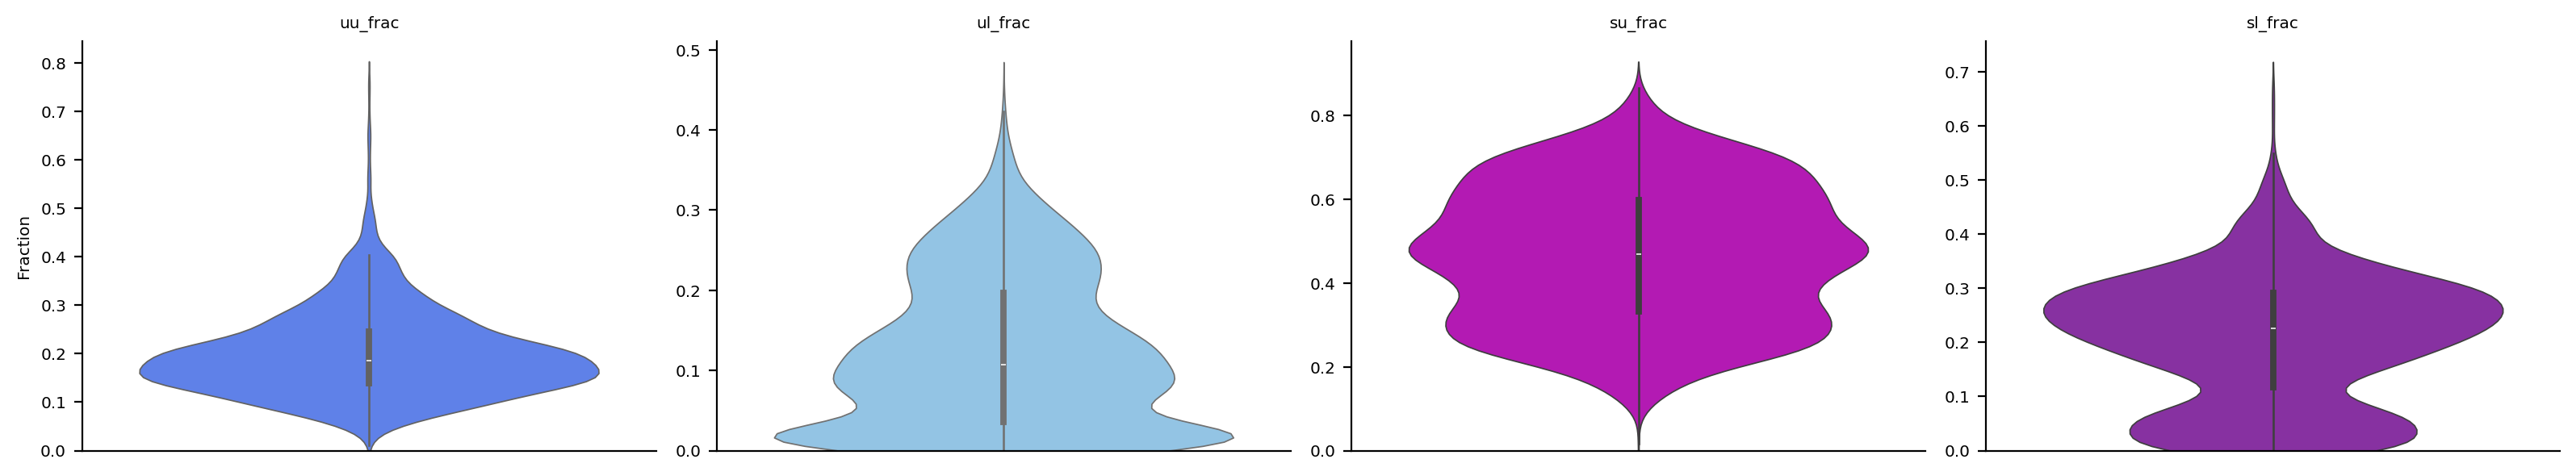

In [8]:
adata = organoid.copy()
adata.obs.time = adata.obs.time.astype('str')
adata.obs.loc[adata.obs['time'] == 'dmso', 'time'] = -1
adata.obs['time'] = adata.obs['time'].astype(float)
adata = adata[adata.obs.time != -1, :]
adata = adata[adata.obs.exp_type == 'Pulse', :]
adata.layers['new'], adata.layers['total'] = adata.layers['ul'] + adata.layers['sl'], adata.layers['su'] + adata.layers['sl'] + adata.layers['uu'] + adata.layers['ul']
del adata.layers['uu'], adata.layers['ul'], adata.layers['su'], adata.layers['sl']
dyn.pp.recipe_monocle(adata, n_top_genes=1000, total_layers=False)
# preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True)
# preprocessor.config_monocle_recipe(adata, n_top_genes=1000)                                  
# preprocessor.preprocess_adata_monocle(adata)
dyn.pl.basic_stats(adata)
dyn.pl.show_fraction(organoid)

In [9]:
adata.obs.time = adata.obs.time/60

In [10]:
adata.obs.time  = adata.obs.time.astype('float')
dyn.tl.dynamics(adata, model='deterministic', tkey='time', assumption_mRNA='ss')

dyn.tl.reduceDimension(adata)

|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----> [moments calculation] completed [18.5947s]
|-----? Your adata only has labeling data, but `NTR_vel` is set to be `False`. Dynamo will reset it to `True` to enable this analysis.


estimating gamma: 100%|██████████| 1000/1000 [00:15<00:00, 64.93it/s]


|-----> retrieve data for non-linear dimension reduction...
|-----> [UMAP] using X_pca with n_pca_components = 30
|-----> <insert> X_umap to obsm in AnnData Object.
|-----> [UMAP] completed [6.8695s]


In [11]:
dyn.tl.cell_velocities(adata, ekey='M_t', 
                       vkey='velocity_T', enforce=True)

|-----> incomplete neighbor graph info detected: connectivities and distances do not exist in adata.obsp, indices not in adata.uns.neighbors.
|-----> Neighbor graph is broken, recomputing....
|-----> Start computing neighbor graph...
|-----------> X_data is None, fetching or recomputing...
|-----> fetching X data from layer:None, basis:pca
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [3.1662s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.4074s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 1373 × 9157
    obs: 'well_id', 'batch_id', 'treatment_id', 'log10_gfp', 'rotated_umap1', 'rotated_umap2', 'som_cluster_id', 'monocle_branch_id', 'monocle_pseudotime', 'exp_type', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'new_Size_Factor', 'initial_new_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'ID', 'NAME', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'pp', 'velocyto_SVR', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'pca_fit', 'feature_selection', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_umap'
    obsm: 'X_pca', 'X', 'cell_cycle_scores', 'X_umap', 'velocity_umap'
    varm: 'alpha', 'vel_params'
    layers: 'new', 'total', 'X_total', 'X_new', 'M_t', 'M_tt'

In [12]:
adata.obsm['X_umap_ori'] = adata.obs.loc[:, ['rotated_umap1', 'rotated_umap2']].values.astype(float)

## Visualize time-resolved vector flow learned with dynamo 

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [0.4296s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


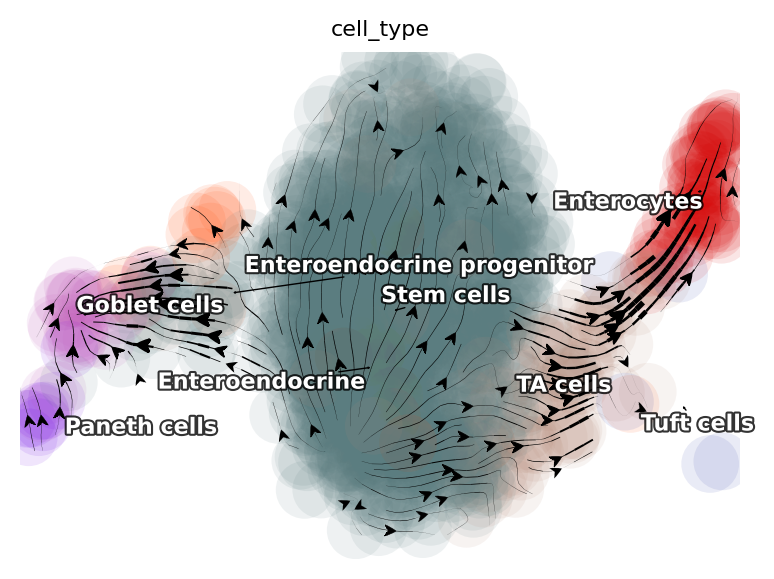

In [13]:
dyn.tl.cell_velocities(adata, basis='umap_ori')

dyn.pl.streamline_plot(adata, color='cell_type', 
                       basis='umap_ori',figsize=(4,3),
                       s_kwargs_dict={'adjust_legend':True},
                      )


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_cycle_phase by stack threshold when stacking color because it is not a numeric type


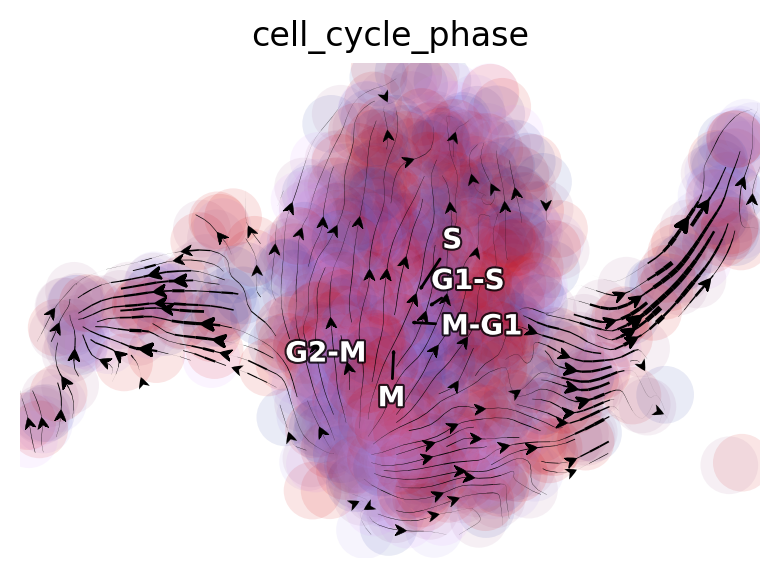

In [14]:
dyn.pl.streamline_plot(adata, color='cell_cycle_phase', 
                       basis='umap_ori',figsize=(4,3),
                       s_kwargs_dict={'adjust_legend':True},
)


In [15]:
adata.var_names[adata.var.use_for_transition][:5]

Index(['Cdc45', 'Brat1', 'Ccnd2', 'Ckmt1', 'Pdgfb'], dtype='object')

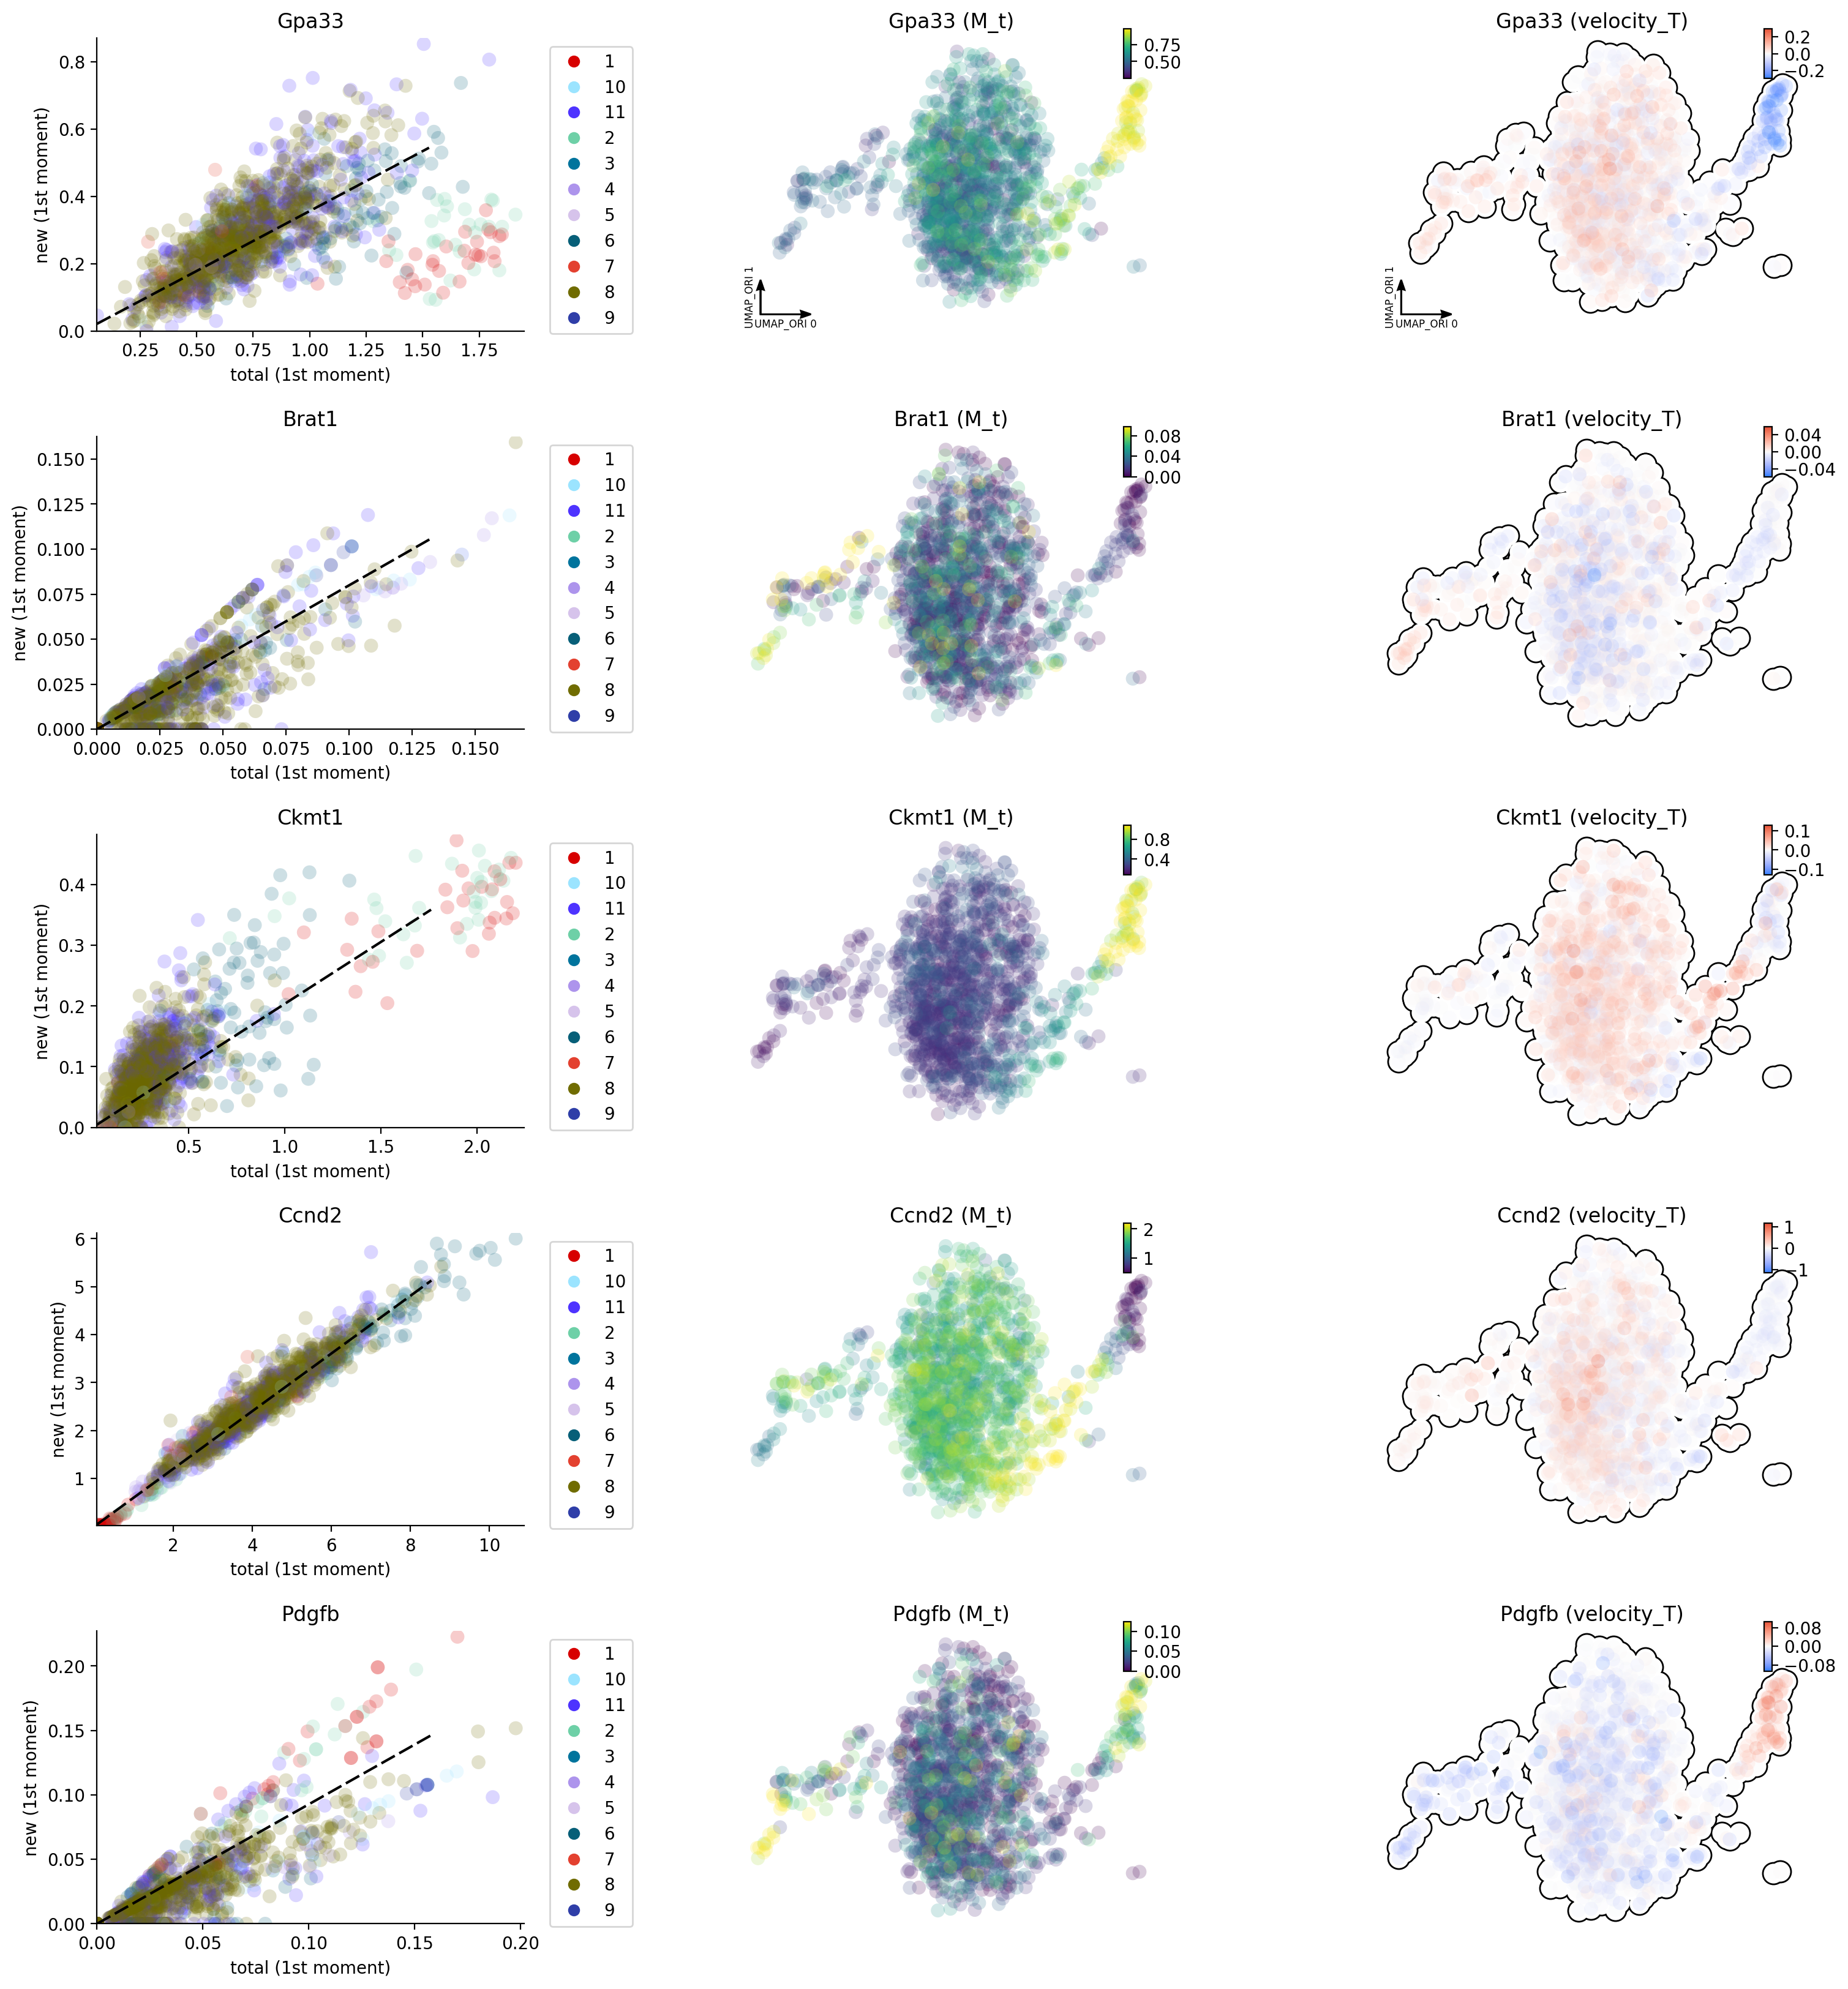

In [17]:
dyn.pl.phase_portraits(adata, genes=['Brat1', 'Ccnd2', 'Ckmt1', 'Pdgfb', 'Gpa33'],
                       color='som_cluster_id', basis='umap_ori')


## Animate intestine organoid differentiation

In [16]:
dyn.vf.VectorField(adata, basis='umap_ori',M=100, pot_curl_div=True, enforce=True)

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP_ORI. 
        Vector field will be learned in the UMAP_ORI space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [7.2004s]
|-----> Running ddhodge to estimate vector field based pseudotime in umap_ori basis...
|-----> graphizing vectorfield...
|-----------? nbrs_idx argument is ignored and recomputed because nbrs_idx is not None and return_nbrs=True
|-----------> calculating neighbor indices...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [ddhodge completed] completed [2.9559s]
|-----> Computing curl...


Calculating 2-D curl: 100%|██████████| 1373/1373 [00:00<00:00, 13311.47it/s]

|-----> Computing divergence...



Calculating divergence: 100%|██████████| 2/2 [00:00<00:00, 19.35it/s]


|-----> [VectorField] completed [10.7233s]


In [17]:
progenitor = adata.obs_names[adata.obs.cell_type == 'Stem cells']
len(progenitor)

1146

In [18]:
np.random.seed(19491001)

from matplotlib import animation
info_genes = adata.var_names[adata.var.use_for_transition]
dyn.pd.fate(adata, basis='umap_ori', init_cells=progenitor[:100], 
            interpolation_num=100,  direction='forward',
   inverse_transform=False, average=False)


uniformly sampling points along a trajectory: 100%|██████████| 100/100 [00:00<00:00, 748.24it/s]


AnnData object with n_obs × n_vars = 1373 × 9157
    obs: 'well_id', 'batch_id', 'treatment_id', 'log10_gfp', 'rotated_umap1', 'rotated_umap2', 'som_cluster_id', 'monocle_branch_id', 'monocle_pseudotime', 'exp_type', 'time', 'cell_type', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'Size_Factor', 'initial_cell_size', 'total_Size_Factor', 'initial_total_cell_size', 'new_Size_Factor', 'initial_new_cell_size', 'ntr', 'cell_cycle_phase', 'umap_ori_ddhodge_div', 'umap_ori_ddhodge_potential', 'curl_umap_ori', 'divergence_umap_ori', 'control_point_umap_ori', 'inlier_prob_umap_ori', 'obs_vf_angle_umap_ori'
    var: 'ID', 'NAME', 'nCells', 'nCounts', 'pass_basic_filter', 'log_cv', 'log_m', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'pp', 'velocyto_SVR', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'pca_fit', 'feature_selection', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_u

|-----> Vector field for umap_ori is but its topography is not mapped. Mapping topography now ...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


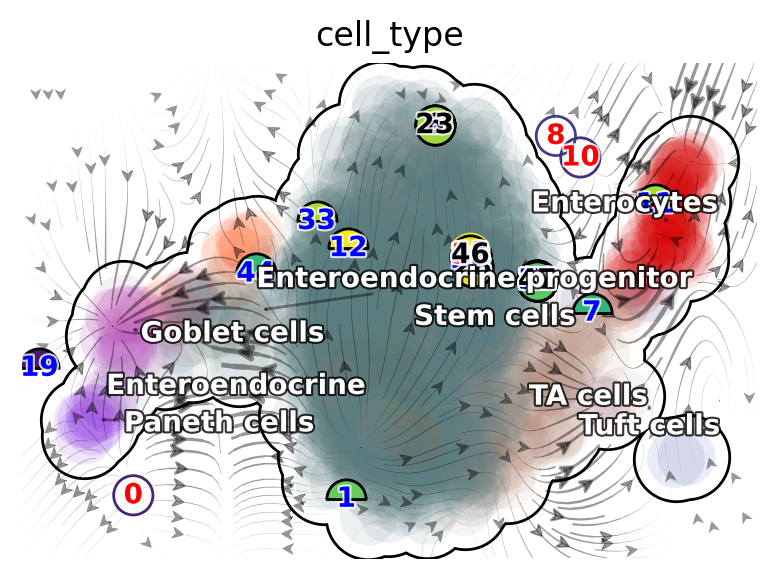

In [19]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4,3))
dyn.pl.topography(adata, basis='umap_ori', background='white', 
                  color=['cell_type'], fps_basis='umap_ori',
                  streamline_color='black', s_kwargs_dict={'adjust_legend':True},
                  show_legend='on data', frontier=True,ax=ax)
ax.set_aspect(0.8)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


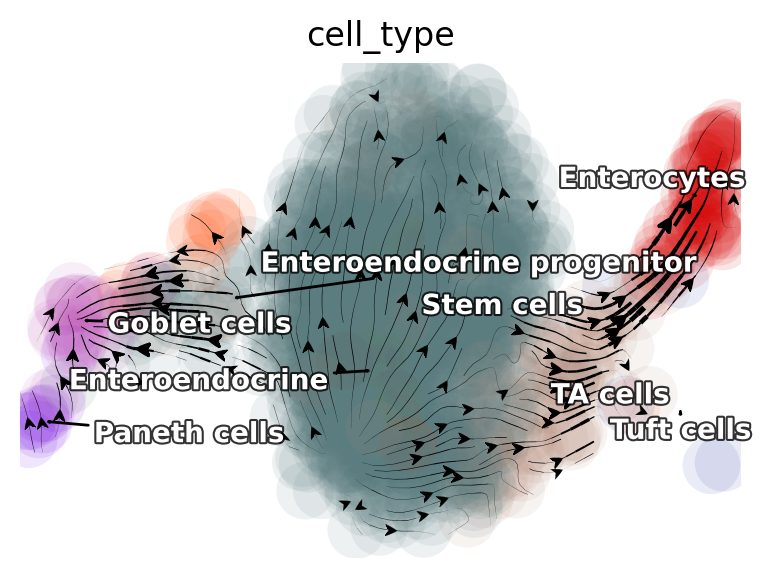

In [20]:
#dyn.tl.cell_velocities(adata, basis='umap_ori')

dyn.pl.streamline_plot(adata, color='cell_type', 
                       basis='umap_ori',figsize=(4,3),
                       s_kwargs_dict={'adjust_legend':True},
                      )


In [22]:
adata.obs['cell_type'].unique()

array(['TA cells', 'Enterocytes', 'Stem cells', 'Enteroendocrine',
       'Goblet cells', 'Paneth cells', 'Enteroendocrine progenitor',
       'Tuft cells'], dtype=object)

In [25]:
color_dict={'TA cells': '#4c644c',
 'Enterocytes': '#2c6c3c',
 'Stem cells': '#347c8c',
 'Enteroendocrine': '#4c8444',
 'Goblet cells': '#e40414',
 'Paneth cells': '#4c1c1c',
 'Enteroendocrine progenitor': '#94a47c',
 'Tuft cells': '#143c3c'}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'Gut:CellType\n[Label]')

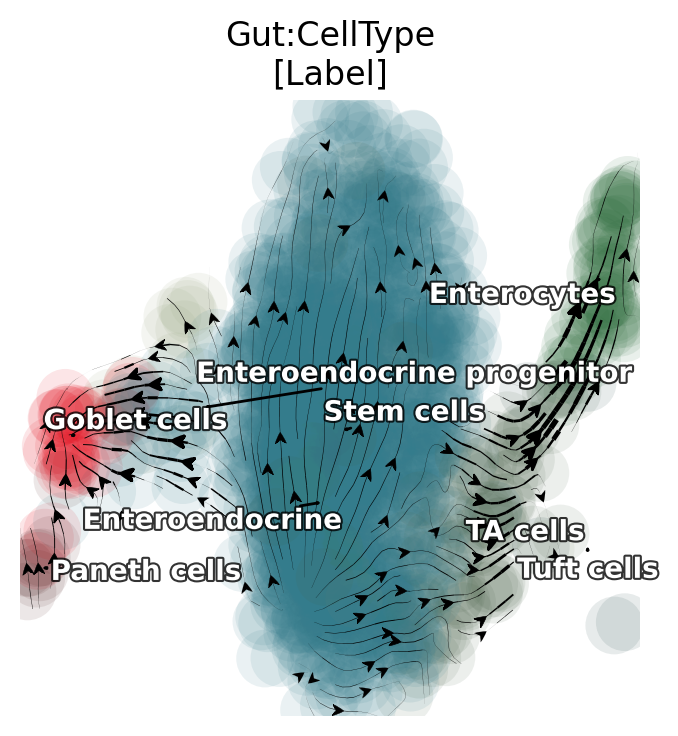

In [27]:
%matplotlib inline
import matplotlib.pyplot as plt
#ov.plot_set()
fig,ax=plt.subplots(1,1,figsize = (4,4))
dyn.pl.streamline_plot(adata, color=['cell_type'], 
                       basis='umap_ori',
                       color_key=color_dict,
                       title='Gut:CellType',
                       show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     },
                       linewidth=1,
                      save_show_or_return='return',ax=ax)
plt.title('Gut:CellType\n[Label]',fontsize=12)
#fig.savefig(f'figures/fig3/Label_Gut_Velo.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'Gut:Topography\n[Label]')

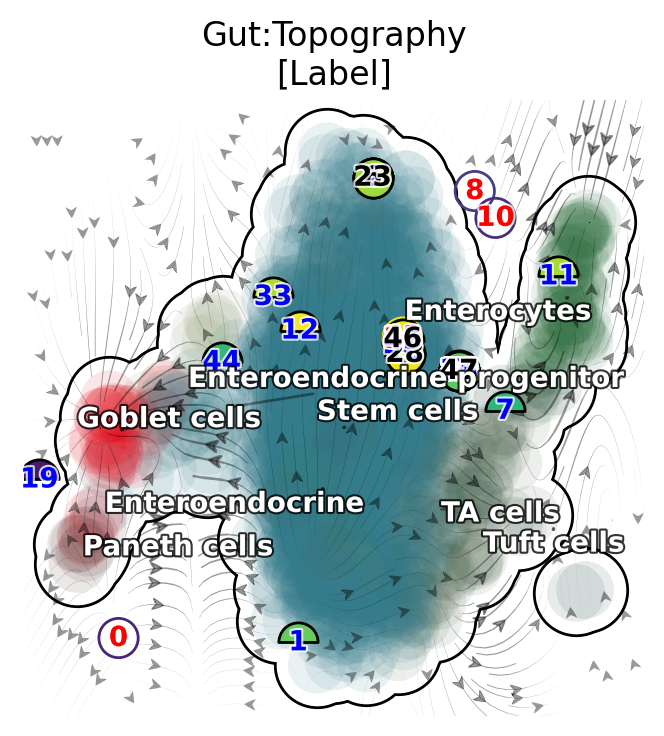

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (4,4))
dyn.pl.topography(adata, basis='umap_ori',
                  fps_basis='umap_ori',background='white', 
                  color=[ 'cell_type'], 
                  color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Gut:Topography\n[Label]',fontsize=12)
#fig.savefig(f'figures/fig3/Label_Gut_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap_ori
|-----------> skip filtering cell_type by stack threshold when stacking color because it is not a numeric type


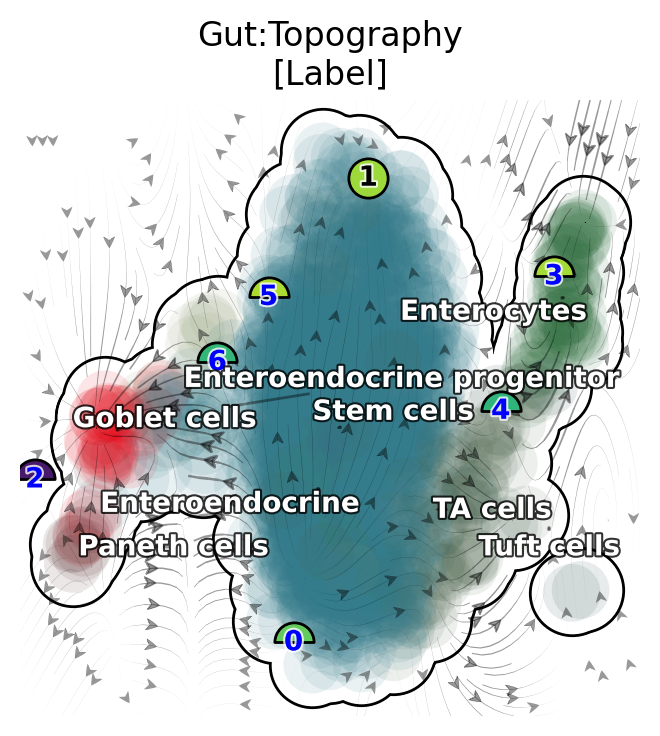

In [31]:
adata_load_fix_points=adata.copy()
Xss, ftype, conf = adata_load_fix_points.uns['VecFld_umap_ori']['Xss'],\
                   adata_load_fix_points.uns['VecFld_umap_ori']['ftype'],\
                   adata_load_fix_points.uns['VecFld_umap_ori']['confidence']

fixed_points = [1,23,19,11,7,33,44]

adata_load_fix_points.uns['VecFld_umap_ori']['Xss'] = Xss[fixed_points]
adata_load_fix_points.uns['VecFld_umap_ori']['ftype'] = ftype[fixed_points]
adata_load_fix_points.uns['VecFld_umap_ori']['confidence']=conf[fixed_points]

import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (4,4))
#ov.plot_set()
dyn.pl.topography(adata_load_fix_points, basis='umap_ori',
                  fps_basis='umap_ori',background='white', 
                  color=[ 'cell_type'], 
                  color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('Gut:Topography\n[Label]',fontsize=12)
#fig.savefig(f'figures/fig3/Label_Gut_Topography.png', dpi=300, bbox_inches='tight')
fig

|-----------> plotting with basis key=X_umap_ori


Text(0.5, 1.0, 'Gut:Potential\n[Label]')

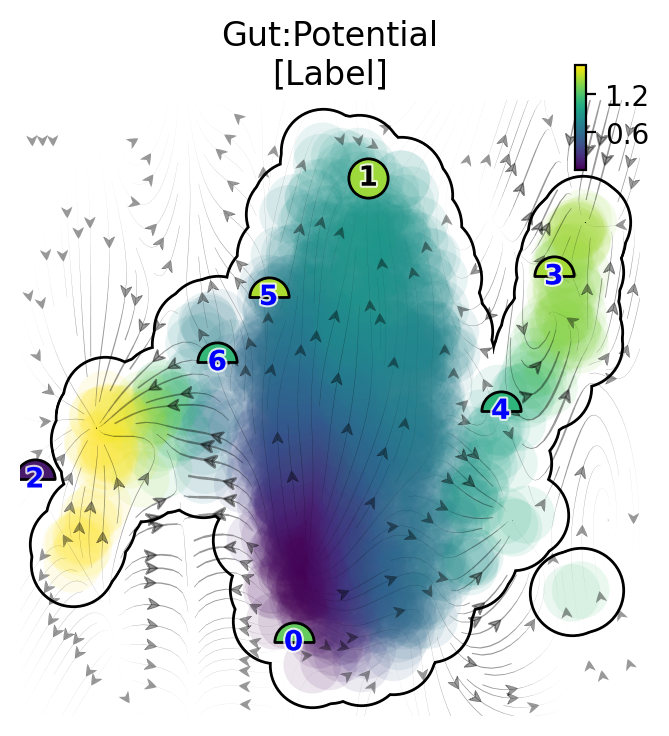

In [33]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (4,4))
dyn.pl.topography(adata_load_fix_points, 
                  basis='umap_ori', fps_basis='umap_ori',
                  background='white', 
                  color=[ 'umap_ori_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                    },
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('Gut:Potential\n[Label]',fontsize=12)
#fig.savefig(f'figures/fig3/Label_Gut_Potential.png', dpi=300, bbox_inches='tight')